## PC3: Benchmark report for /similarMoviesSeq (sequential) and /similarMoviesCon (concurrent)

This report runs multiple requests against the two API endpoints provided by the PC3 server and collects the reported `timeMongoMs` and `timeAlgoMs` fields plus the wall-clock duration of each HTTP request. It varies the number of repetitions and, for the concurrent endpoint, the `workers` parameter.

How to use:
- Start the PC3 server (it listens on port 8080).
- Edit and run the code cell below to set the repeated counts and the worker values you want to test.
- The code will save results to `pc3_benchmark_results.csv` in the notebook directory and show summary tables and plots.

Running SEQ tests: repetitions list = [3, 5]
  -> 3 runs for sequential endpoint


SEQ x3:   0%|          | 0/3 [00:00<?, ?it/s]

  -> 5 runs for sequential endpoint


SEQ x5:   0%|          | 0/5 [00:00<?, ?it/s]

Running CON tests: repetitions list = [3, 5] with workers = [1, 2, 4, 6, 8]
  -> workers = 1
     -> 3 runs for concurrent endpoint with 1 workers


...

  -> workers = 8
     -> 3 runs for concurrent endpoint with 8 workers


CON w=8 x3:   0%|          | 0/3 [00:00<?, ?it/s]

     -> 5 runs for concurrent endpoint with 8 workers


CON w=8 x5:   0%|          | 0/5 [00:00<?, ?it/s]

Saved results to pc3_benchmark_results.csv

Aggregated results (mean ± std):
  endpoint  workers  runs_for_setting  timeMongo_mean  timeMongo_std  \
0      con      1.0                 3             1.0            0.0   
1      con      1.0                 5             1.0            0.0   
2      con      2.0                 3             1.0            0.0   
3      con      2.0                 5             1.0            0.0   
4      con      4.0                 3             1.0            0.0   
5      con      4.0                 5             1.0            0.0   
6      con      6.0                 3             1.0            0.0   
7      con      6.0                 5             1.0            0.0   
8      con      8.0                 3             1.0            0.0   
9      con      8.0                 5             1.0            0.0   

   timeAlgo_mean  timeAlgo_std  reqDur_mean  reqDur_std  count  
0     869.333333     50.143128   872.667710   50.222305      3  


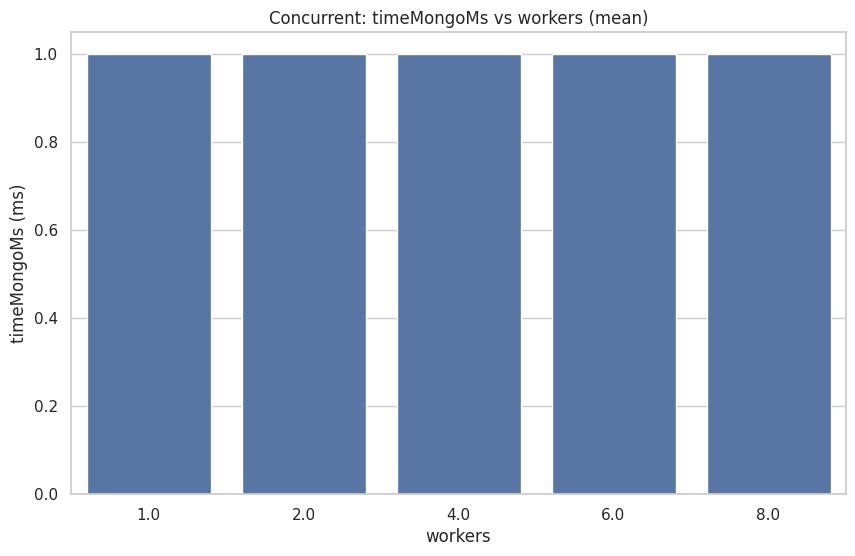

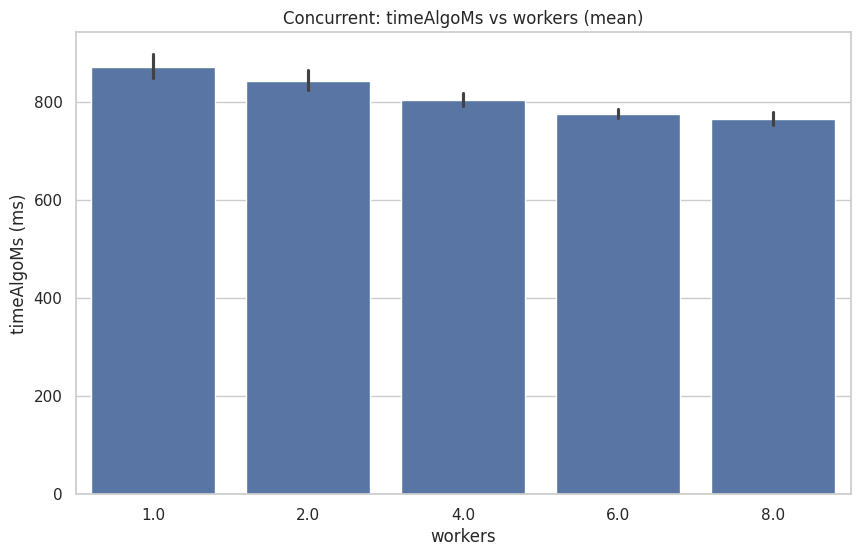

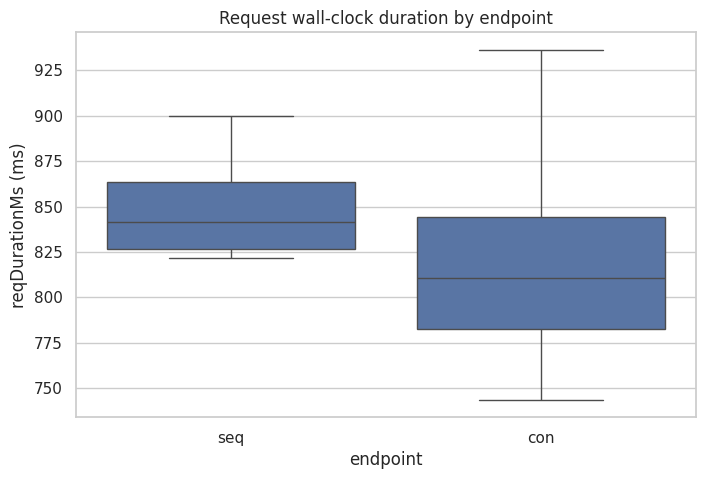

,endpoint,workers,runs_for_setting,rep_index,timeMongoMs,timeAlgoMs,reqDurationMs
0,seq,NaN,3,1,1,895,900.033951
1,seq,NaN,3,2,1,852,854.949474
2,seq,NaN,3,3,1,827,830.327749
3,seq,NaN,5,1,1,818,821.590424
4,seq,NaN,5,2,1,886,889.605522
5,seq,NaN,5,3,1,823,826.790810
6,seq,NaN,5,4,1,849,852.945805
7,seq,NaN,5,5,1,823,826.382875
8,con,1.0,3,1,1,845,848.099470
9,con,1.0,3,2,1,927,930.444479


In [1]:
# Benchmarking code: call endpoints, collect timings, save results and plot
import requests
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

BASE_URL = 'http://localhost:8080'
SEQ_ENDPOINT = BASE_URL + '/similarMoviesSeq'
CON_ENDPOINT = BASE_URL + '/similarMoviesCon'

# helper callers
def call_seq(user_id):
    r = requests.get(SEQ_ENDPOINT, params={'userId': user_id}, timeout=60)
    r.raise_for_status()
    return r.json()

def call_con(user_id, workers):
    r = requests.get(CON_ENDPOINT, params={'userId': user_id, 'workers': workers}, timeout=60)
    r.raise_for_status()
    return r.json()

# main benchmark function
def run_bench(reps_seq, reps_con, workers_list, user_id=1):
    rows = []

    print(f"Running SEQ tests: repetitions list = {reps_seq}")
    for n in reps_seq:
        print(f"  -> {n} runs for sequential endpoint")
        for i in tqdm(range(n), desc=f"SEQ x{n}"):
            t0 = time.time()
            try:
                js = call_seq(user_id)
            except Exception as e:
                print('SEQ request error:', e)
                continue
            dur = (time.time() - t0) * 1000.0
            rows.append({
                'endpoint': 'seq',
                'workers': None,
                'runs_for_setting': n,
                'rep_index': i + 1,
                'timeMongoMs': js.get('timeMongoMs'),
                'timeAlgoMs': js.get('timeAlgoMs'),
                'reqDurationMs': dur
            })

    print(f"Running CON tests: repetitions list = {reps_con} with workers = {workers_list}")
    for w in workers_list:
        print(f"  -> workers = {w}")
        for n in reps_con:
            print(f"     -> {n} runs for concurrent endpoint with {w} workers")
            for i in tqdm(range(n), desc=f"CON w={w} x{n}"):
                t0 = time.time()
                try:
                    js = call_con(user_id, w)
                except Exception as e:
                    print('CON request error:', e)
                    continue
                dur = (time.time() - t0) * 1000.0
                rows.append({
                    'endpoint': 'con',
                    'workers': w,
                    'runs_for_setting': n,
                    'rep_index': i + 1,
                    'timeMongoMs': js.get('timeMongoMs'),
                    'timeAlgoMs': js.get('timeAlgoMs'),
                    'reqDurationMs': dur
                })

    df = pd.DataFrame(rows)
    return df

# Default parameters (edit these before running the cell):
# - reps_seq: list of counts, each count is the number of times to repeat the sequential endpoint
# - reps_con: list of counts, each count is the number of times to repeat for each workers setting
# - workers_list: list of workers to test for /similarMoviesCon

reps_seq = [3, 5]          # e.g., test seq with 3 and 5 runs
reps_con = [3, 5]          # e.g., for each worker count, do 3 and 5 runs
workers_list = [1, 2, 4, 6, 8]
user_id = 40

# Run benchmark (this will perform HTTP calls — ensure the server is running):
results_df = run_bench(reps_seq=reps_seq, reps_con=reps_con, workers_list=workers_list, user_id=user_id)

# Save results and show summary
csv_path = 'pc3_benchmark_results.csv'
results_df.to_csv(csv_path, index=False)
print(f"Saved results to {csv_path}")

# Aggregated stats
agg = results_df.groupby(['endpoint', 'workers', 'runs_for_setting']).agg(
    timeMongo_mean=('timeMongoMs', 'mean'),
    timeMongo_std=('timeMongoMs', 'std'),
    timeAlgo_mean=('timeAlgoMs', 'mean'),
    timeAlgo_std=('timeAlgoMs', 'std'),
    reqDur_mean=('reqDurationMs', 'mean'),
    reqDur_std=('reqDurationMs', 'std'),
    count=('reqDurationMs', 'count')
).reset_index()

print('\nAggregated results (mean ± std):')
print(agg)

# Plots
sns.set(style='whitegrid')

# For concurrent endpoint: mongo time vs workers
plt.figure(figsize=(10,6))
con_df = results_df[results_df['endpoint'] == 'con']
if not con_df.empty:
    sns.barplot(data=con_df, x='workers', y='timeMongoMs', estimator=np.mean)
    plt.title('Concurrent: timeMongoMs vs workers (mean)')
    plt.ylabel('timeMongoMs (ms)')
    plt.show()

    plt.figure(figsize=(10,6))
    sns.barplot(data=con_df, x='workers', y='timeAlgoMs', estimator=np.mean)
    plt.title('Concurrent: timeAlgoMs vs workers (mean)')
    plt.ylabel('timeAlgoMs (ms)')
    plt.show()

# overall request duration by endpoint
plt.figure(figsize=(8,5))
if not results_df.empty:
    sns.boxplot(data=results_df, x='endpoint', y='reqDurationMs')
    plt.title('Request wall-clock duration by endpoint')
    plt.ylabel('reqDurationMs (ms)')
    plt.show()

# Show raw head
results_df.head(20)
